## **Train a vanilla RNN actor-critic on a context-value lick task**
Author: patrick.mccarthy@dpag.ox.ac.uk

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

from cxval.tasks import ValueMatrix, StimulusSequence, StateSequence
from cxval.envs import TaskEnv
from cxval.models import RNN, ActorCritic
from cxval.agents import Agent
from cxval.vis import STYLE

plt.style.use(STYLE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Generate task

In [ ]:
n_contexts = 3
n_stimuli  = 5
contexts = [f"c{i}" for i in range(n_contexts)]
stimuli  = [f"s{i}" for i in range(n_stimuli)]

trials_per_phase    = 100
phases_per_context  = 1
context_reps        = 10
stim_timesteps      = 5
reward_timesteps    = 3
iti_timesteps       = (3, 8)
seed                = 42

val_matrix = ValueMatrix(
    seed=seed, contexts=contexts, stimuli=stimuli,
    delta_context=0.15, base_lower=0.1, base_upper=0.9,
)
val_matrix.generate_base_values(seed=seed)
value_matrix = val_matrix.generate_value_matrix(seed=seed)

stim_seq = StimulusSequence(
    value_matrix=value_matrix,
    trials_per_phase=trials_per_phase,
    phases_per_context=phases_per_context,
    context_order="sequential",
    context_reps=context_reps,
)
stim_seq.generate(seed=seed)

state_seq = StateSequence(
    stimulus_sequence=stim_seq,
    value_matrix=value_matrix,
    stim_timesteps=stim_timesteps,
    reward_timesteps=reward_timesteps,
    iti_timesteps=iti_timesteps,
)
states, rewards, reward_availability = state_seq.generate(seed=seed)

n_trials = len(stim_seq.trial_contexts)
obs_dim  = states.shape[1] + 2  # base + [rewarded, unrewarded]

print(f"States shape:    {states.shape}  (pre-feedback)")
print(f"Obs dim (model): {obs_dim}")
print(f"Trials:          {n_trials}")
print(f"Sequence length: {len(states)} timesteps")
print(f"\nValue matrix (stimuli x contexts):")
print(np.round(value_matrix, 2))

In [16]:
task_data_path = Path("../task_data")
task_data_path.mkdir(exist_ok=True)

task_data = {
    "states": states,
    "rewards": rewards,
    "reward_availability": reward_availability,
    "trial_structure": state_seq.trial_structure,
    "value_matrix": value_matrix,
    "params": {
        "n_contexts": n_contexts, "n_stimuli": n_stimuli,
        "trials_per_phase": trials_per_phase, "phases_per_context": phases_per_context,
        "stim_timesteps": stim_timesteps, "reward_timesteps": reward_timesteps,
        "iti_timesteps": iti_timesteps, "seed": seed,
    },
}

save_path = task_data_path / f"10_05_26_{n_contexts}c{n_stimuli}s_seed{seed}.pkl"
with open(save_path, "wb") as f:
    pickle.dump(task_data, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved → {save_path}")

Saved → ../task_data/10_05_26_3c5s_seed42.pkl


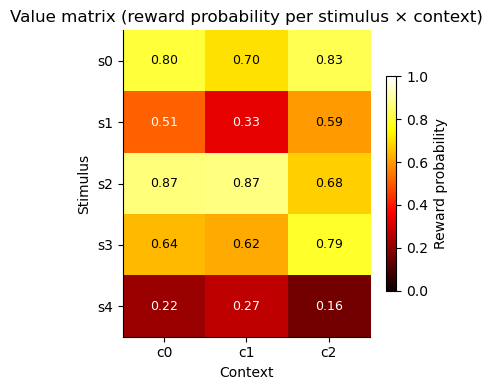

In [17]:
# ── value matrix heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(4, n_contexts), max(3, n_stimuli * 0.8)))
im = ax.imshow(value_matrix, cmap="hot", vmin=0, vmax=1, aspect="auto")

for i in range(n_stimuli):
    for j in range(n_contexts):
        v = value_matrix[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v < 0.55 else "black", fontsize=9)

ax.set_yticks(range(n_stimuli))
ax.set_xticks(range(n_contexts))
ax.set_yticklabels(stimuli)
ax.set_xticklabels(contexts)
ax.set_ylabel("Stimulus")
ax.set_xlabel("Context")
ax.set_title("Value matrix (reward probability per stimulus × context)")
plt.colorbar(im, ax=ax, shrink=0.7, label="Reward probability")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr

# ── Spearman rank correlation of stimulus values across contexts ───────────
spearman_mat = np.array([[spearmanr(value_matrix[:, ci], value_matrix[:, cj])[0]
                           for cj in range(n_contexts)]
                          for ci in range(n_contexts)])

cell_size = 1.1
fig, ax = plt.subplots(figsize=(cell_size * n_contexts + 1, cell_size * n_contexts))
im = ax.imshow(spearman_mat, vmin=-1, vmax=1, cmap="seismic", aspect="equal")

for i in range(n_contexts):
    for j in range(n_contexts):
        ax.text(j, i, f"{spearman_mat[i, j]:.2f}", ha="center", va="center",
                fontsize=10, fontweight="bold" if i == j else "normal")

ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts)
ax.set_yticks(range(n_contexts)); ax.set_yticklabels(contexts)
ax.set_xlabel("Context"); ax.set_ylabel("Context")
ax.set_title("Spearman rank correlation of stimulus values across contexts")
plt.colorbar(im, ax=ax, shrink=0.8, label="Spearman r")
plt.tight_layout()
plt.show()

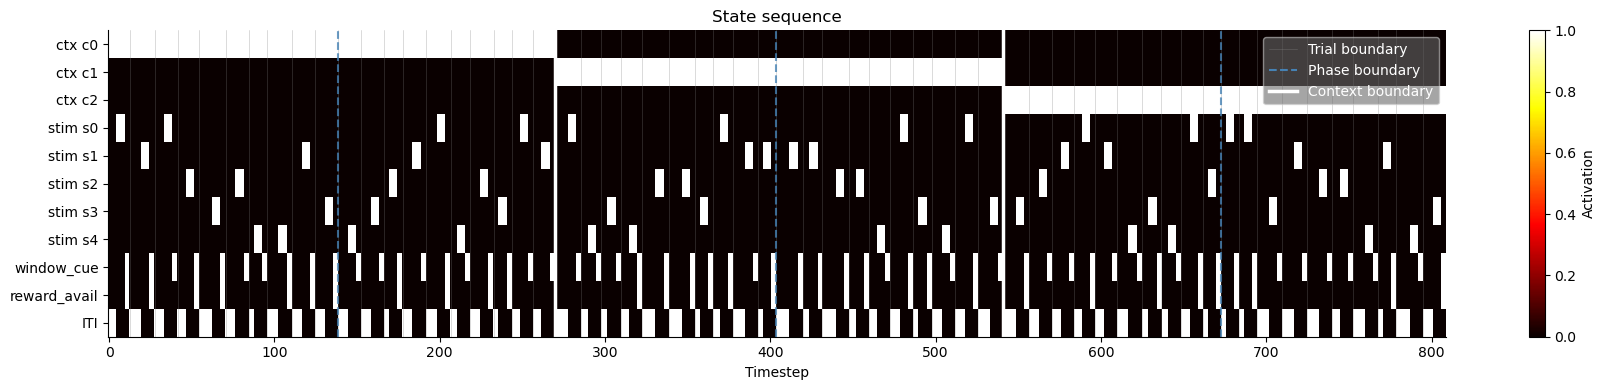

In [18]:
from matplotlib.lines import Line2D
from collections import defaultdict

# ── state-sequence heatmap ─────────────────────────────────────────────────
trial_starts = np.array([t["trial_start"] for t in state_seq.trial_structure])
trial_ends   = np.array([t["trial_end"]   for t in state_seq.trial_structure])
trial_bnd_ts = np.append(trial_starts, trial_ends[-1])

context_at_trial = np.array([t["context"] for t in state_seq.trial_structure])
ctx_change_idx   = np.where(np.diff(context_at_trial) != 0)[0] + 1
context_bnd_ts   = trial_starts[ctx_change_idx]

# phase within context (0 = first block, 1 = second block, …)
_cc = defaultdict(int)
phase_at_trial = np.zeros(n_trials, dtype=int)
for _i, _c in enumerate(context_at_trial):
    phase_at_trial[_i] = _cc[_c] // trials_per_phase
    _cc[_c] += 1
phase_change_idx = np.where(
    (np.diff(phase_at_trial) != 0) & (np.diff(context_at_trial) == 0)
)[0] + 1
phase_bnd_ts = trial_starts[phase_change_idx]

iti_indicator = (
    (states[:, n_contexts : n_contexts + n_stimuli].sum(axis=1) == 0) &
    (states[:, -1] == 0)
).astype(float)

vis_states = np.vstack([
    states.T,
    reward_availability[None, :],
    iti_indicator[None, :],
])
ylabels = (
    [f"ctx {c}" for c in contexts]
    + [f"stim {s}" for s in stimuli]
    + ["window_cue", "reward_avail", "ITI"]
)

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(vis_states, aspect="auto", cmap="hot", vmin=0, vmax=1, interpolation="nearest")

for t in trial_bnd_ts[1:-1]:
    ax.axvline(t - 0.5, color="gray", linewidth=0.4, alpha=0.5)
for t in phase_bnd_ts:
    ax.axvline(t - 0.5, color="steelblue", linewidth=1.5, linestyle="--", alpha=0.8)
for t in context_bnd_ts:
    ax.axvline(t - 0.5, color="white", linewidth=2.5)

ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels)
ax.set_xlabel("Timestep")
ax.set_title("State sequence")
plt.colorbar(im, ax=ax, label="Activation")

ax.legend(
    handles=[
        Line2D([0],[0], color="gray",      linewidth=0.4, alpha=0.6, label="Trial boundary"),
        Line2D([0],[0], color="steelblue", linewidth=1.5, linestyle="--", label="Phase boundary"),
        Line2D([0],[0], color="white",     linewidth=2.5, label="Context boundary"),
    ],
    loc="upper right", framealpha=0.6, facecolor="dimgray", labelcolor="white",
)
plt.tight_layout()
plt.show()

## 2. Environment and model

In [ ]:
lick_cost    = 0.0    # penalty for licking when no reward available, any timestep (0 = off)
policy_clip  = 0.05   # min probability for any action; prevents collapse to 0 (0 = off)

env = TaskEnv(
    states=states,
    reward_availability=reward_availability,
    reward_lick=1.0,
    reward_no_lick=0.0,
    reward_lick_miss=-1.0,
    lick_cost=lick_cost,
)

hidden_size    = 64
num_actions    = 2        # 0 = lick, 1 = no-lick
recurrent_gain = 0.9

backbone     = RNN(input_size=obs_dim, hidden_size=hidden_size, output_size=1,
                   recurrent_gain=recurrent_gain)
actor_critic = ActorCritic(backbone=backbone, num_actions=num_actions,
                           policy_clip=policy_clip).to(device)
agent        = Agent(actor_critic, device=device)

n_params = sum(p.numel() for p in actor_critic.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"policy_clip={policy_clip}  lick_cost={lick_cost}")

## 3. Train

In [ ]:
def compute_returns(rewards, bootstrap_value, gamma):
    """Discounted returns with a bootstrap value at the end of the chunk."""
    returns, R = [], float(bootstrap_value)
    for r in reversed(rewards):
        R = r + gamma * R
        returns.append(R)
    returns.reverse()
    return returns

In [ ]:
n_episodes   = 1
update_every = 200   # timesteps between gradient updates
gamma        = 0.9
lr           = 3e-4
value_coef   = 0.5
entropy_coef = 0.01
grad_clip    = 1.0

optimizer = torch.optim.Adam(actor_critic.parameters(), lr=lr)

episode_rewards       = []
lick_rates_rewarded   = []
lick_rates_unrewarded = []
actor_losses          = []   # one entry per gradient update
critic_losses         = []
all_trial_data        = []
hidden_np_train       = None   # hidden states from the last episode, set below

for episode in range(n_episodes):
    obs, _ = env.reset()
    hidden = None
    actor_critic.train()

    log_probs_buf, values_buf, rewards_buf, entropies_buf = [], [], [], []
    action_list, reward_list, info_list = [], [], []
    value_ts = []

    is_last = (episode == n_episodes - 1)
    if is_last:
        hidden_ts_list = []

    done = False
    t    = 0

    while not done:
        obs_t  = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits, value, hidden = actor_critic.step(obs_t, hidden)
        dist   = actor_critic.make_dist(logits)
        action = dist.sample()

        log_probs_buf.append(dist.log_prob(action))
        values_buf.append(value)
        entropies_buf.append(dist.entropy())
        value_ts.append(value.detach().item())

        if is_last:
            hidden_ts_list.append(hidden.detach().squeeze(0))

        action_list.append(action.item())
        obs, reward, done, _, info = env.step(action.item())
        rewards_buf.append(reward)
        reward_list.append(reward)
        info_list.append(info)
        t += 1

        if t % update_every == 0 or done:
            if done:
                bootstrap_v = 0.0
            else:
                with torch.no_grad():
                    obs_next = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                    _, bv, _ = actor_critic.step(obs_next, hidden)
                    bootstrap_v = bv.item()

            returns      = compute_returns(rewards_buf, bootstrap_v, gamma)
            log_probs_t  = torch.stack(log_probs_buf).squeeze(-1)
            values_t     = torch.stack(values_buf).squeeze(-1)
            returns_t    = torch.tensor(returns, dtype=torch.float32, device=device)
            entropy_mean = torch.stack(entropies_buf).mean()

            advantages = returns_t - values_t.detach()
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            actor_loss  = -(log_probs_t * advantages).mean()
            critic_loss = F.mse_loss(values_t, returns_t)
            loss        = actor_loss + value_coef * critic_loss - entropy_coef * entropy_mean

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(actor_critic.parameters(), grad_clip)
            optimizer.step()

            hidden = hidden.detach()
            actor_losses.append(actor_loss.item())
            critic_losses.append(critic_loss.item())

            log_probs_buf, values_buf, rewards_buf, entropies_buf = [], [], [], []

    if is_last:
        hidden_np_train = np.array(torch.stack(hidden_ts_list).tolist(), dtype=np.float32)

    for ti, trial in enumerate(state_seq.trial_structure):
        rs, re = trial["reward_window"]
        all_trial_data.append({
            "episode":          episode,
            "global_trial":     episode * n_trials + ti,
            "context":          trial["context"],
            "stimulus":         trial["stimulus"],
            "reward_available": trial["reward_available"],
            "licked":           int(action_list[rs] == TaskEnv.LICK),
            "value_estimate":   float(np.mean(value_ts[rs:re])),
            "lick_count":       sum(1 for a in action_list[rs:re] if a == TaskEnv.LICK),
        })

    episode_rewards.append(sum(reward_list))
    in_window = np.array([i["in_reward_window"] for i in info_list])
    avail     = np.array([i["reward_available"]  for i in info_list])
    licks     = (np.array(action_list) == TaskEnv.LICK).astype(float)
    rew_mask   = in_window & avail
    unrew_mask = in_window & ~avail
    lick_rates_rewarded.append(  licks[rew_mask].mean()   if rew_mask.any()   else np.nan)
    lick_rates_unrewarded.append(licks[unrew_mask].mean() if unrew_mask.any() else np.nan)

    print_every = max(1, n_episodes // 10)
    if (episode + 1) % print_every == 0:
        r      = np.mean(episode_rewards[-print_every:])
        n_upd  = len(actor_losses)
        print(f"ep {episode+1:4d}/{n_episodes} | reward {r:+7.1f} | updates so far: {n_upd}")

print(f"Training hidden states shape: {hidden_np_train.shape}")

## 4. Results

In [ ]:
def smooth(x, w):
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x, np.arange(len(x))
    return np.convolve(x, np.ones(w) / w, mode="valid"), np.arange(w - 1, len(x))

upd_w = max(1, min(50, len(actor_losses) // 10))

fig, ax = plt.subplots(figsize=(6, 3.5))
s_a, x_a = smooth(actor_losses,  upd_w)
s_c, x_c = smooth(critic_losses, upd_w)
ax.plot(x_a, s_a, label="actor")
ax.plot(x_c, s_c, label="critic", linestyle="--")
ax.set_title("Loss (per gradient update)")
ax.set_xlabel("Update step")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── per-stimulus training performance ─────────────────────────────────────
td = np.array([
    (d["episode"], d["global_trial"], d["context"], d["stimulus"],
     d["reward_available"], d["licked"], d["value_estimate"], d["lick_count"])
    for d in all_trial_data
])
# cols: 0=episode 1=global_trial 2=context 3=stimulus 4=reward_available
#       5=licked(1st rew step) 6=value_estimate 7=lick_count

# context block geometry (within one episode)
_ctx_arr         = np.array([t["context"] for t in state_seq.trial_structure])
_chg_idx         = np.where(np.diff(_ctx_arr) != 0)[0] + 1
ctx_block_starts = np.concatenate([[0], _chg_idx])
ctx_block_ends   = np.concatenate([_chg_idx, [n_trials]])
ctx_block_ctxs   = _ctx_arr[ctx_block_starts]

ctx_colors  = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]
stim_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

n_total_trials = len(all_trial_data) // n_stimuli
smooth_w = max(1, min(30, n_total_trials // 10))

fig, axes = plt.subplots(4, 1, figsize=(15, 11),
                         gridspec_kw={"height_ratios": [3, 2.5, 2.5, 1], "hspace": 0.45})

# shade context blocks across all episodes (rows 0–2 only)
for ep in range(n_episodes):
    for bs, be, ctx in zip(ctx_block_starts, ctx_block_ends, ctx_block_ctxs):
        x0 = ep * n_trials + bs - 0.5
        x1 = ep * n_trials + be - 0.5
        for ax in axes[:3]:
            ax.axvspan(x0, x1, alpha=0.15, color=ctx_colors[ctx], zorder=0, linewidth=0)

for si in range(n_stimuli):
    mask        = td[:, 3] == si
    gt          = td[mask, 1].astype(int)
    val         = td[mask, 6]
    lick        = td[mask, 5]
    lick_rate_w = td[mask, 7] / reward_timesteps

    c = stim_colors[si % len(stim_colors)]
    if smooth_w > 1:
        sv  = np.convolve(val,         np.ones(smooth_w) / smooth_w, mode="valid")
        sl  = np.convolve(lick,        np.ones(smooth_w) / smooth_w, mode="valid")
        slr = np.convolve(lick_rate_w, np.ones(smooth_w) / smooth_w, mode="valid")
        xax = gt[smooth_w - 1:]
    else:
        sv, sl, slr, xax = val, lick, lick_rate_w, gt

    axes[0].plot(xax, sv,  color=c, linewidth=1.2, label=stimuli[si])
    axes[1].plot(xax, sl,  color=c, linewidth=1.2)
    axes[2].plot(xax, slr, color=c, linewidth=1.2)
    axes[0].axhline(value_matrix[si].mean(), color=c, linestyle=":", linewidth=0.8, alpha=0.55)

stim_handles = [Line2D([0],[0], color=stim_colors[si % len(stim_colors)], label=stimuli[si])
                for si in range(n_stimuli)]
ctx_handles  = [Patch(facecolor=ctx_colors[c], alpha=0.6, label=contexts[c])
                for c in range(n_contexts)]

axes[0].legend(handles=stim_handles + ctx_handles, ncol=n_stimuli + n_contexts, fontsize=8, loc="upper left")
axes[0].set_ylabel("Value estimate")
axes[0].set_title("Per-stimulus value estimate  (dotted = mean reward probability)")

axes[1].legend(handles=stim_handles, ncol=n_stimuli, fontsize=8, loc="upper left")
axes[1].set_ylabel("Lick prob.\n(1st rew. step)")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title("Lick probability at first reward window timestep")

axes[2].set_ylabel("Lick rate\n(all rew. steps)")
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_xlabel("Global trial index")
axes[2].set_title(f"Mean lick rate across all reward window timesteps ({reward_timesteps} ts)")

# ── trial structure schematic ──────────────────────────────────────────────
ax = axes[3]
avg_iti   = state_seq.iti_durations.mean()
total_ts  = avg_iti + stim_timesteps + reward_timesteps
iti_frac  = avg_iti / total_ts
stim_frac = stim_timesteps / total_ts

for xstart, xend, color, label in [
    (0,                    iti_frac,             "lightgray", f"ITI (~{avg_iti:.0f} ts, jittered)"),
    (iti_frac,             iti_frac + stim_frac, "#4C72B0",   f"Stim ({stim_timesteps} ts)"),
    (iti_frac + stim_frac, 1.0,                  "#DD8452",   f"Reward window ({reward_timesteps} ts)"),
]:
    ax.barh(0, xend - xstart, left=xstart, height=0.5, color=color)
    ax.text((xstart + xend) / 2, 0, label, ha="center", va="center", fontsize=8,
            color="black" if color == "lightgray" else "white")

lick_x = iti_frac + stim_frac   # start of reward window
ax.annotate("lick sampled\n(row 2 above)", xy=(lick_x, 0.25), xytext=(lick_x + 0.07, 1.0),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0), fontsize=7, ha="center")

ax.set_xlim(0, 1)
ax.set_ylim(-0.6, 1.6)
ax.axis("off")
ax.set_title(f"Trial structure (mean total ≈ {total_ts:.0f} ts)", fontsize=8, loc="left", pad=2)

plt.show()

In [ ]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ── performance metrics ────────────────────────────────────────────────────
licked_arr     = np.array([d["licked"]           for d in all_trial_data])
rew_avail      = np.array([d["reward_available"]  for d in all_trial_data]).astype(bool)
stim_idx_arr   = np.array([d["stimulus"]          for d in all_trial_data])
ctx_idx_arr    = np.array([d["context"]           for d in all_trial_data])
lick_count_arr = np.array([d["lick_count"]        for d in all_trial_data])

pct_reward_consumed = licked_arr[rew_avail].mean()  * 100 if  rew_avail.any() else np.nan
false_alarm_rate    = licked_arr[~rew_avail].mean() * 100 if (~rew_avail).any() else np.nan
lick_rate_window    = lick_count_arr.mean() / reward_timesteps * 100

stim_colors_p = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ctx_markers   = ["o", "s", "^"]

lick_probs_flat, reward_probs_flat = [], []

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax_sc = axes[0]

for si in range(n_stimuli):
    for ci in range(n_contexts):
        mask_sc = (stim_idx_arr == si) & (ctx_idx_arr == ci)
        if mask_sc.sum() == 0:
            continue
        lp = licked_arr[mask_sc].mean()
        rp = float(value_matrix[si, ci])
        lick_probs_flat.append(lp)
        reward_probs_flat.append(rp)
        ax_sc.scatter(rp, lp,
                      color=stim_colors_p[si % len(stim_colors_p)],
                      marker=ctx_markers[ci % len(ctx_markers)],
                      s=80, zorder=3)
        ax_sc.annotate(f"{stimuli[si]},{contexts[ci]}", (rp, lp),
                       textcoords="offset points", xytext=(5, 3), fontsize=7)

lick_probs_flat   = np.array(lick_probs_flat)
reward_probs_flat = np.array(reward_probs_flat)
r_sp = spearmanr(reward_probs_flat, lick_probs_flat)[0] if len(lick_probs_flat) > 1 else np.nan

ax_sc.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5, label="ideal")
ax_sc.set_xlim(-0.05, 1.05); ax_sc.set_ylim(-0.05, 1.05)
ax_sc.set_xlabel("Reward probability"); ax_sc.set_ylabel("Lick probability")
ax_sc.set_title(f"Lick–value calibration  (Spearman r = {r_sp:.3f})")

stim_h = [Line2D([0],[0], color=stim_colors_p[si % len(stim_colors_p)],
                 marker="o", linestyle="none", label=stimuli[si]) for si in range(n_stimuli)]
ctx_h  = [Line2D([0],[0], color="gray",
                 marker=ctx_markers[ci % len(ctx_markers)], linestyle="none",
                 label=contexts[ci]) for ci in range(n_contexts)]
ax_sc.legend(handles=stim_h + ctx_h, fontsize=8, ncol=2, loc="upper left")

ax_bar = axes[1]
bars = ax_bar.bar(
    ["Reward\nconsumed (%)", "False alarm\nrate (%)", "Lick rate\nin window (%)"],
    [pct_reward_consumed, false_alarm_rate, lick_rate_window],
    color=["steelblue", "salmon", "gray"], width=0.5,
)
ax_bar.set_ylim(0, 110); ax_bar.set_ylabel("%")
ax_bar.set_title("Performance summary")
for bar, val in zip(bars, [pct_reward_consumed, false_alarm_rate, lick_rate_window]):
    if not np.isnan(val):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, val + 1,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
from collections import defaultdict

def t2np(tensor):
    """Convert a CPU tensor to numpy, bypassing the PyTorch-numpy bridge."""
    return np.array(tensor.detach().cpu().tolist(), dtype=np.float32)

# ── final eval pass ────────────────────────────────────────────────────────
actor_critic.eval()
obs, _ = env.reset()
agent.reset()

obs_seq, action_seq = [], []
done = False
while not done:
    obs_seq.append(obs.copy())
    action, _, _ = agent.act(obs)
    action_seq.append(action)
    obs, _, done, _, _ = env.step(action)

with torch.no_grad():
    obs_t = torch.FloatTensor(np.stack(obs_seq)).unsqueeze(0).to(device)
    _, _, hidden_all = actor_critic(obs_t)
hidden_np = t2np(hidden_all.squeeze(0))   # (T, hidden_size)

# ── trial-level metadata ───────────────────────────────────────────────────
context_arr          = np.array([t["context"]          for t in state_seq.trial_structure])
stimulus_arr         = np.array([t["stimulus"]         for t in state_seq.trial_structure])
reward_available_arr = np.array([t["reward_available"] for t in state_seq.trial_structure])

# phase: which repetition of this context block (0-indexed within context)
_cc = defaultdict(int)
phase_arr = np.zeros(n_trials, dtype=int)
for i, ctx in enumerate(context_arr):
    phase_arr[i] = _cc[ctx] // trials_per_phase
    _cc[ctx] += 1

action_arr   = np.array([action_seq[t["reward_window"][0]] for t in state_seq.trial_structure])
rewarded_arr = (action_arr == TaskEnv.LICK) & reward_available_arr

# ── pre-extract fixed-length epoch activations ─────────────────────────────
stim_hidden = np.stack([
    hidden_np[t["stim_window"][0]   : t["stim_window"][1]]
    for t in state_seq.trial_structure
])   # (n_trials, stim_timesteps, hidden_size)

reward_hidden = np.stack([
    hidden_np[t["reward_window"][0] : t["reward_window"][1]]
    for t in state_seq.trial_structure
])   # (n_trials, reward_timesteps, hidden_size)

# ── structured activations dict ────────────────────────────────────────────
activations = {
    "hidden_states":    hidden_np,           # (T, hidden_size)          full sequence
    "stim_hidden":      stim_hidden,         # (n_trials, stim_ts, H)   stimulus epoch
    "reward_hidden":    reward_hidden,       # (n_trials, rew_ts,  H)   reward epoch
    "context":          context_arr,         # (n_trials,) int
    "stimulus":         stimulus_arr,        # (n_trials,) int
    "phase":            phase_arr,           # (n_trials,) int  0 = first block of this context
    "reward_available": reward_available_arr,# (n_trials,) bool
    "action":           action_arr,          # (n_trials,) int  0=lick 1=no-lick
    "rewarded":         rewarded_arr,        # (n_trials,) bool
    "trial_structure":  state_seq.trial_structure,
}

print(f"hidden_states : {hidden_np.shape}")
print(f"stim_hidden   : {stim_hidden.shape}")
print(f"reward_hidden : {reward_hidden.shape}")
print(f"phases present: {np.unique(phase_arr)}")

mask = (activations["context"] == 0) & (activations["phase"] == 0) & (activations["stimulus"] == 2)
print(f"\nExample — ctx=0, phase=0, stim=2 → {mask.sum()} trials, "
      f"stim_hidden: {activations['stim_hidden'][mask].shape}")

In [ ]:
from matplotlib.patches import Patch

# ── epoch-mean activations ─────────────────────────────────────────────────
iti_hidden_mean = np.array([
    hidden_np[t["iti_window"][0]:t["iti_window"][1]].mean(0)
    if t["iti_window"][1] > t["iti_window"][0] else np.zeros(hidden_np.shape[1])
    for t in state_seq.trial_structure
])   # (n_trials, H)

stim_hidden_mean   = activations["stim_hidden"].mean(1)    # (n_trials, H)
reward_hidden_mean = activations["reward_hidden"].mean(1)  # (n_trials, H)

ctx_arr  = activations["context"]
stim_arr = activations["stimulus"]

epochs_data = [
    ("ITI",    iti_hidden_mean),
    ("Stim",   stim_hidden_mean),
    ("Reward", reward_hidden_mean),
]

all_vals = np.concatenate([d.ravel() for _, d in epochs_data])
vmin_act, vmax_act = np.percentile(all_vals, 2), np.percentile(all_vals, 98)

ctx_colors  = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]
stim_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(n_stimuli, 3, figsize=(12, 2.5 * n_stimuli), sharey=True)

for si in range(n_stimuli):
    mask     = stim_arr == si
    ctx_this = ctx_arr[mask]

    chg        = np.where(np.diff(ctx_this) != 0)[0] + 1 if ctx_this.size > 1 else np.array([], dtype=int)
    blk_starts = np.concatenate([[0], chg])
    blk_ends   = np.concatenate([chg, [mask.sum()]])
    blk_ctxs   = ctx_this[blk_starts]

    for col, (epoch_name, epoch_data) in enumerate(epochs_data):
        ax   = axes[si, col]
        data = epoch_data[mask]   # (n_trials_si, H)

        im = ax.imshow(data.T, aspect="auto", cmap="viridis",
                       vmin=vmin_act, vmax=vmax_act, interpolation="nearest")

        for bs, be, ctx in zip(blk_starts, blk_ends, blk_ctxs):
            ax.axvspan(bs - 0.5, be - 0.5, alpha=0.2,
                       color=ctx_colors[ctx], zorder=2, linewidth=0)

        if si == 0:
            ax.set_title(epoch_name, fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{stimuli[si]}\nUnit", fontsize=8)
        if si == n_stimuli - 1:
            ax.set_xlabel("Trial", fontsize=8)
        ax.tick_params(labelsize=7)

fig.colorbar(im, ax=axes, shrink=0.5, label="Activation", pad=0.02)

ctx_handles = [Patch(facecolor=ctx_colors[c], alpha=0.7, label=contexts[c])
               for c in range(n_contexts)]
axes[0, -1].legend(handles=ctx_handles, loc="upper right", fontsize=7, framealpha=0.7)

plt.suptitle("Mean hidden-state activations per epoch (rows = stimuli)", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
from itertools import combinations
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# ── parameters ─────────────────────────────────────────────────────────────
pooling = "average"   # "average": one vector per trial | "pool": one vector per timestep (trial-level CV)
n_folds = 5

# ── decoder ────────────────────────────────────────────────────────────────
def pairwise_decode(act_dict, period, pooling, n_folds=5, random_state=42):
    """5-fold CV pairwise linear SVM decoder, balanced by downsampling.

    Returns acc array of shape (n_contexts, n_stimuli, n_stimuli); diagonal is NaN.
    """
    ctx_arr  = act_dict["context"]
    stim_arr = act_dict["stimulus"]
    hidden   = act_dict["stim_hidden" if period == "stim" else "reward_hidden"]

    n_stim = int(stim_arr.max()) + 1
    n_ctx  = int(ctx_arr.max()) + 1
    acc    = np.full((n_ctx, n_stim, n_stim), np.nan)

    rng = np.random.default_rng(random_state)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    for c in range(n_ctx):
        for si, sj in combinations(range(n_stim), 2):
            h_i = hidden[(ctx_arr == c) & (stim_arr == si)]
            h_j = hidden[(ctx_arr == c) & (stim_arr == sj)]

            n_min = min(len(h_i), len(h_j))
            if n_min < 2:
                continue

            h_i = h_i[rng.choice(len(h_i), n_min, replace=False)]
            h_j = h_j[rng.choice(len(h_j), n_min, replace=False)]

            h_all   = np.concatenate([h_i, h_j], axis=0)
            y_trial = np.array([0] * n_min + [1] * n_min)

            if 2 * n_min < n_folds * 2:
                continue

            ts, H = h_all.shape[1], h_all.shape[2]
            fold_accs = []
            for train_idx, test_idx in skf.split(np.arange(2 * n_min), y_trial):
                if pooling == "average":
                    X_tr, y_tr = h_all[train_idx].mean(1), y_trial[train_idx]
                    X_te, y_te = h_all[test_idx].mean(1),  y_trial[test_idx]
                else:
                    X_tr = h_all[train_idx].reshape(-1, H)
                    X_te = h_all[test_idx].reshape(-1, H)
                    y_tr = np.repeat(y_trial[train_idx], ts)
                    y_te = np.repeat(y_trial[test_idx],  ts)

                sc   = StandardScaler().fit(X_tr)
                clf  = LinearSVC(max_iter=2000, dual="auto").fit(sc.transform(X_tr), y_tr)
                fold_accs.append(clf.score(sc.transform(X_te), y_te))

            a = np.mean(fold_accs)
            acc[c, si, sj] = a
            acc[c, sj, si] = a

    return acc

stim_acc   = pairwise_decode(activations, period="stim",   pooling=pooling, n_folds=n_folds)
reward_acc = pairwise_decode(activations, period="reward", pooling=pooling, n_folds=n_folds)

# ── plot ───────────────────────────────────────────────────────────────────
ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]

cell_size = 0.7
fig, axes = plt.subplots(2, n_contexts,
                         figsize=(cell_size * n_stimuli * n_contexts,
                                  cell_size * n_stimuli * 2),
                         squeeze=False)

for row, (period_name, acc) in enumerate([("Stim", stim_acc), ("Reward", reward_acc)]):
    for c in range(n_contexts):
        ax  = axes[row, c]
        mat = acc[c].copy()
        np.fill_diagonal(mat, np.nan)

        im = ax.imshow(mat, vmin=0, vmax=1, cmap="seismic", aspect="equal")

        for i in range(n_stimuli):
            for j in range(n_stimuli):
                if not np.isnan(mat[i, j]):
                    ax.text(j, i, f"{mat[i, j]:.2f}",
                            ha="center", va="center", fontsize=8)

        ax.set_xticks(range(n_stimuli)); ax.set_xticklabels(stimuli, fontsize=8)
        ax.set_yticks(range(n_stimuli)); ax.set_yticklabels(stimuli, fontsize=8)

        if row == 0:
            ax.set_title(contexts[c], color=ctx_colors[c], fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{period_name} period\nStimulus i")
        ax.set_xlabel("Stimulus j")

        plt.colorbar(im, ax=ax, shrink=0.8, label="Accuracy")

fig.suptitle(
    f"Pairwise stimulus decoding  ·  linear SVM  ·  {pooling} pooling  ·  {n_folds}-fold CV  ·  white = chance (0.5)",
    y=1.02, fontsize=11,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── cross-context generalisation ──────────────────────────────────────────
def crosscontext_decode(act_dict, period, pooling, random_state=42):
    """Returns cross_acc of shape (n_ctx_train, n_ctx_test, n_stim, n_stim); diagonal NaN."""
    ctx_arr  = act_dict["context"]
    stim_arr = act_dict["stimulus"]
    hidden   = act_dict["stim_hidden" if period == "stim" else "reward_hidden"]

    n_stim = int(stim_arr.max()) + 1
    n_ctx  = int(ctx_arr.max()) + 1
    cross_acc = np.full((n_ctx, n_ctx, n_stim, n_stim), np.nan)

    rng = np.random.default_rng(random_state)
    ts, H = hidden.shape[1], hidden.shape[2]

    for c_train in range(n_ctx):
        for c_test in range(n_ctx):
            if c_train == c_test:
                continue
            for si, sj in combinations(range(n_stim), 2):
                tr_i = hidden[(ctx_arr == c_train) & (stim_arr == si)]
                tr_j = hidden[(ctx_arr == c_train) & (stim_arr == sj)]
                te_i = hidden[(ctx_arr == c_test)  & (stim_arr == si)]
                te_j = hidden[(ctx_arr == c_test)  & (stim_arr == sj)]

                if any(len(x) == 0 for x in [tr_i, tr_j, te_i, te_j]):
                    continue

                n_tr = min(len(tr_i), len(tr_j))
                n_te = min(len(te_i), len(te_j))
                tr_i = tr_i[rng.choice(len(tr_i), n_tr, replace=False)]
                tr_j = tr_j[rng.choice(len(tr_j), n_tr, replace=False)]
                te_i = te_i[rng.choice(len(te_i), n_te, replace=False)]
                te_j = te_j[rng.choice(len(te_j), n_te, replace=False)]

                if pooling == "average":
                    X_tr = np.vstack([tr_i.mean(1), tr_j.mean(1)])
                    X_te = np.vstack([te_i.mean(1), te_j.mean(1)])
                    y_tr = np.array([0] * n_tr + [1] * n_tr)
                    y_te = np.array([0] * n_te + [1] * n_te)
                else:
                    X_tr = np.vstack([tr_i.reshape(-1, H), tr_j.reshape(-1, H)])
                    X_te = np.vstack([te_i.reshape(-1, H), te_j.reshape(-1, H)])
                    y_tr = np.array([0] * (n_tr * ts) + [1] * (n_tr * ts))
                    y_te = np.array([0] * (n_te * ts) + [1] * (n_te * ts))

                sc  = StandardScaler().fit(X_tr)
                clf = LinearSVC(max_iter=2000, dual="auto").fit(sc.transform(X_tr), y_tr)
                a   = clf.score(sc.transform(X_te), y_te)
                cross_acc[c_train, c_test, si, sj] = a
                cross_acc[c_train, c_test, sj, si] = a

    return cross_acc

cross_stim_acc   = crosscontext_decode(activations, period="stim",   pooling=pooling)
cross_reward_acc = crosscontext_decode(activations, period="reward", pooling=pooling)

# ── summary matrices ───────────────────────────────────────────────────────
def mean_pairs(mat):
    vals = [mat[i, j] for i, j in combinations(range(mat.shape[0]), 2)
            if not np.isnan(mat[i, j])]
    return np.nanmean(vals) if vals else np.nan

def generalisation_matrix(within_acc, cross_acc):
    n_ctx = within_acc.shape[0]
    gm = np.full((n_ctx, n_ctx), np.nan)
    for c in range(n_ctx):
        gm[c, c] = mean_pairs(within_acc[c])
    for ct, ce in combinations(range(n_ctx), 2):
        gm[ct, ce] = mean_pairs(cross_acc[ct, ce])
        gm[ce, ct] = mean_pairs(cross_acc[ce, ct])
    return gm

gen_stim   = generalisation_matrix(stim_acc,   cross_stim_acc)
gen_reward = generalisation_matrix(reward_acc, cross_reward_acc)

# ── plot ───────────────────────────────────────────────────────────────────
ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]

cell_size = 1.1
fig, axes = plt.subplots(1, 2,
                         figsize=(cell_size * n_contexts * 2 + 1,
                                  cell_size * n_contexts),
                         squeeze=False)

for ax, (period_name, gm) in zip(axes[0], [("Stim", gen_stim), ("Reward", gen_reward)]):
    im = ax.imshow(gm, vmin=0, vmax=1, cmap="seismic", aspect="equal")

    for i in range(n_contexts):
        for j in range(n_contexts):
            if not np.isnan(gm[i, j]):
                ax.text(j, i, f"{gm[i, j]:.2f}",
                        ha="center", va="center", fontsize=10,
                        fontweight="bold" if i == j else "normal")

    ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts, fontsize=9)
    ax.set_yticks(range(n_contexts)); ax.set_yticklabels(contexts, fontsize=9)
    ax.set_xlabel("Test context")
    ax.set_ylabel("Train context")
    ax.set_title(f"{period_name} period")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Accuracy")

    for tick, c in zip(ax.get_xticklabels(), range(n_contexts)):
        tick.set_color(ctx_colors[c])
    for tick, c in zip(ax.get_yticklabels(), range(n_contexts)):
        tick.set_color(ctx_colors[c])

fig.suptitle(
    f"Cross-context stimulus generalisation  ·  linear SVM  ·  {pooling} pooling\n"
    f"diagonal = within-context ({n_folds}-fold CV)  ·  off-diagonal = trained→tested across contexts  ·  white = chance (0.5)",
    fontsize=10, y=1.03,
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

# ── value decoding ─────────────────────────────────────────────────────────
def value_decode_within(act_dict, period, pooling, value_matrix, n_folds=5, random_state=42):
    """Within-context Ridge regression with k-fold CV. Returns Pearson r per context."""
    ctx_arr  = act_dict["context"]
    stim_arr = act_dict["stimulus"]
    hidden   = act_dict["stim_hidden" if period == "stim" else "reward_hidden"]
    ts, H    = hidden.shape[1], hidden.shape[2]

    n_ctx    = int(ctx_arr.max()) + 1
    r_within = np.full(n_ctx, np.nan)
    kf       = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    for c in range(n_ctx):
        mask = ctx_arr == c
        y    = value_matrix[stim_arr[mask], c]
        X    = hidden[mask].mean(1) if pooling == "average" else hidden[mask].reshape(-1, H)
        if pooling != "average":
            y = np.repeat(y, ts)

        y_pred = np.full(len(y), np.nan)
        for train_idx, test_idx in kf.split(X):
            sc = StandardScaler().fit(X[train_idx])
            y_pred[test_idx] = Ridge().fit(sc.transform(X[train_idx]), y[train_idx]) \
                                       .predict(sc.transform(X[test_idx]))

        r_within[c] = pearsonr(y, y_pred)[0]

    return r_within


def value_decode_cross(act_dict, period, pooling, value_matrix):
    """Cross-context value decoding. Returns Pearson r[n_ctx_train, n_ctx_test]; diagonal NaN."""
    ctx_arr  = act_dict["context"]
    stim_arr = act_dict["stimulus"]
    hidden   = act_dict["stim_hidden" if period == "stim" else "reward_hidden"]
    ts, H    = hidden.shape[1], hidden.shape[2]

    n_ctx   = int(ctx_arr.max()) + 1
    r_cross = np.full((n_ctx, n_ctx), np.nan)

    for c_train in range(n_ctx):
        mask_tr = ctx_arr == c_train
        y_tr    = value_matrix[stim_arr[mask_tr], c_train]
        X_tr    = hidden[mask_tr].mean(1) if pooling == "average" else hidden[mask_tr].reshape(-1, H)
        if pooling != "average":
            y_tr = np.repeat(y_tr, ts)

        sc  = StandardScaler().fit(X_tr)
        clf = Ridge().fit(sc.transform(X_tr), y_tr)

        for c_test in range(n_ctx):
            if c_test == c_train:
                continue
            mask_te = ctx_arr == c_test
            y_te    = value_matrix[stim_arr[mask_te], c_test]
            X_te    = hidden[mask_te].mean(1) if pooling == "average" else hidden[mask_te].reshape(-1, H)
            if pooling != "average":
                y_te = np.repeat(y_te, ts)

            y_pred = clf.predict(sc.transform(X_te))
            r_cross[c_train, c_test] = pearsonr(y_te, y_pred)[0]

    return r_cross


def value_gen_matrix(r_within, r_cross):
    gm = r_cross.copy()
    np.fill_diagonal(gm, r_within)
    return gm


r_within_stim   = value_decode_within(activations, period="stim",   pooling=pooling,
                                       value_matrix=value_matrix, n_folds=n_folds)
r_within_reward = value_decode_within(activations, period="reward", pooling=pooling,
                                       value_matrix=value_matrix, n_folds=n_folds)
r_cross_stim    = value_decode_cross(activations,  period="stim",   pooling=pooling,
                                      value_matrix=value_matrix)
r_cross_reward  = value_decode_cross(activations,  period="reward", pooling=pooling,
                                      value_matrix=value_matrix)

gm_stim   = value_gen_matrix(r_within_stim,   r_cross_stim)
gm_reward = value_gen_matrix(r_within_reward, r_cross_reward)

# ── plot ───────────────────────────────────────────────────────────────────
ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]

cell_size = 1.1
fig, axes = plt.subplots(1, 2,
                         figsize=(cell_size * n_contexts * 2 + 1,
                                  cell_size * n_contexts),
                         squeeze=False)

for ax, (period_name, gm) in zip(axes[0], [("Stim", gm_stim), ("Reward", gm_reward)]):
    im = ax.imshow(gm, vmin=-1, vmax=1, cmap="seismic", aspect="equal")

    for i in range(n_contexts):
        for j in range(n_contexts):
            if not np.isnan(gm[i, j]):
                ax.text(j, i, f"{gm[i, j]:.2f}",
                        ha="center", va="center", fontsize=10,
                        fontweight="bold" if i == j else "normal")

    ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts, fontsize=9)
    ax.set_yticks(range(n_contexts)); ax.set_yticklabels(contexts, fontsize=9)
    ax.set_xlabel("Test context")
    ax.set_ylabel("Train context")
    ax.set_title(f"{period_name} period")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")

    for tick, c in zip(ax.get_xticklabels(), range(n_contexts)):
        tick.set_color(ctx_colors[c])
    for tick, c in zip(ax.get_yticklabels(), range(n_contexts)):
        tick.set_color(ctx_colors[c])

fig.suptitle(
    f"Value decoding generalisation  ·  Ridge regression  ·  {pooling} pooling\n"
    f"diagonal = within-context ({n_folds}-fold CV)  ·  off-diagonal = trained→tested across contexts  ·  white = r=0",
    fontsize=10, y=1.03,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── per-repetition decoding ────────────────────────────────────────────────
# Run all decoding analyses separately for each context block repetition (phase)
# to track how representations evolve across the session.

def filter_act_dict(act_dict, mask):
    """Return a copy of act_dict with trial-indexed arrays filtered by mask."""
    n_trials = len(act_dict["context"])
    return {k: v[mask] if (isinstance(v, np.ndarray) and
                            v.ndim > 0 and v.shape[0] == n_trials and
                            k != "hidden_states")
               else v
            for k, v in act_dict.items()}

def mean_offdiag(mat):
    """Mean of off-diagonal entries of a 2-D matrix, ignoring NaN."""
    mask = ~np.eye(mat.shape[0], dtype=bool)
    return np.nanmean(mat[mask])

n_phases = int(activations["phase"].max()) + 1
phases   = np.arange(n_phases)

# storage arrays: (n_phases, n_contexts) for within, (n_phases, n_ctx, n_ctx) for cross
within_stim_ph  = np.full((n_phases, n_contexts), np.nan)
cross_stim_ph   = np.full((n_phases, n_contexts, n_contexts), np.nan)
within_val_ph   = np.full((n_phases, n_contexts), np.nan)
cross_val_ph    = np.full((n_phases, n_contexts, n_contexts), np.nan)

for p in range(n_phases):
    print(f"phase {p+1}/{n_phases}", end="\r")
    act_p = filter_act_dict(activations, activations["phase"] == p)

    acc_p = pairwise_decode(act_p, period="stim", pooling=pooling, n_folds=n_folds)
    for c in range(n_contexts):
        within_stim_ph[p, c] = mean_pairs(acc_p[c])

    cx_p = crosscontext_decode(act_p, period="stim", pooling=pooling)
    for ct in range(n_contexts):
        for ce in range(n_contexts):
            if ct != ce:
                cross_stim_ph[p, ct, ce] = mean_pairs(cx_p[ct, ce])

    within_val_ph[p] = value_decode_within(act_p, period="stim", pooling=pooling,
                                            value_matrix=value_matrix, n_folds=n_folds)
    cross_val_ph[p]  = value_decode_cross(act_p,  period="stim", pooling=pooling,
                                           value_matrix=value_matrix)
print("done")

# mean cross-context per phase (average over all off-diagonal context pairs)
mean_cross_stim_ph = np.array([mean_offdiag(cross_stim_ph[p]) for p in range(n_phases)])
mean_cross_val_ph  = np.array([mean_offdiag(cross_val_ph[p])  for p in range(n_phases)])

# ── plot ───────────────────────────────────────────────────────────────────
ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# within-context stimulus decoding
for c in range(n_contexts):
    axes[0, 0].plot(phases, within_stim_ph[:, c], color=ctx_colors[c], label=contexts[c], marker="o", ms=4)
axes[0, 0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0, 0].set_ylabel("Mean pairwise accuracy")
axes[0, 0].set_title("Stimulus decoding — within context")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_ylim(0, 1)

# cross-context stimulus decoding (mean over pairs, individual pairs faint)
for ct in range(n_contexts):
    for ce in range(n_contexts):
        if ct != ce:
            axes[0, 1].plot(phases, cross_stim_ph[:, ct, ce], color="gray", alpha=0.3, linewidth=0.8)
axes[0, 1].plot(phases, mean_cross_stim_ph, color="black", linewidth=1.5, marker="o", ms=4, label="mean")
axes[0, 1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("Stimulus decoding — cross-context")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend(fontsize=8)

# within-context value decoding
for c in range(n_contexts):
    axes[1, 0].plot(phases, within_val_ph[:, c], color=ctx_colors[c], label=contexts[c], marker="o", ms=4)
axes[1, 0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1, 0].set_ylabel("Pearson r")
axes[1, 0].set_xlabel("Context repetition")
axes[1, 0].set_title("Value decoding — within context")
axes[1, 0].set_ylim(-1, 1)

# cross-context value decoding
for ct in range(n_contexts):
    for ce in range(n_contexts):
        if ct != ce:
            axes[1, 1].plot(phases, cross_val_ph[:, ct, ce], color="gray", alpha=0.3, linewidth=0.8)
axes[1, 1].plot(phases, mean_cross_val_ph, color="black", linewidth=1.5, marker="o", ms=4, label="mean")
axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1, 1].set_xlabel("Context repetition")
axes[1, 1].set_title("Value decoding — cross-context")
axes[1, 1].set_ylim(-1, 1)
axes[1, 1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xticks(phases)

fig.suptitle(f"Decoding by context repetition  ·  stim period  ·  {pooling} pooling", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from collections import defaultdict

# ── build activations_train from last-episode hidden states ────────────────
stim_hidden_tr = np.stack([
    hidden_np_train[t["stim_window"][0] : t["stim_window"][1]]
    for t in state_seq.trial_structure
])   # (n_trials, stim_timesteps, hidden_size)

reward_hidden_tr = np.stack([
    hidden_np_train[t["reward_window"][0] : t["reward_window"][1]]
    for t in state_seq.trial_structure
])   # (n_trials, reward_timesteps, hidden_size)

_cc_tr = defaultdict(int)
phase_arr_tr = np.zeros(n_trials, dtype=int)
for i, ctx in enumerate(context_arr):
    phase_arr_tr[i] = _cc_tr[ctx] // trials_per_phase
    _cc_tr[ctx] += 1

activations_train = {
    "hidden_states":    hidden_np_train,
    "stim_hidden":      stim_hidden_tr,
    "reward_hidden":    reward_hidden_tr,
    "context":          context_arr,
    "stimulus":         stimulus_arr,
    "phase":            phase_arr_tr,
    "reward_available": reward_available_arr,
    "trial_structure":  state_seq.trial_structure,
}

n_phases_tr = int(phase_arr_tr.max()) + 1
print(f"Training hidden states : {hidden_np_train.shape}")
print(f"Phases in training     : {n_phases_tr}")

# ── per-phase decoding on training-time activations ────────────────────────
ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]
cell_size  = 1.1

fig, axes = plt.subplots(
    2, n_phases_tr,
    figsize=(cell_size * n_contexts * n_phases_tr + 1, cell_size * n_contexts * 2 + 1),
    squeeze=False,
)

for p in range(n_phases_tr):
    print(f"  phase {p+1}/{n_phases_tr}", end="\r")
    act_p = filter_act_dict(activations_train, phase_arr_tr == p)

    # stim generalisation matrix
    acc_p  = pairwise_decode(act_p, period="stim", pooling=pooling, n_folds=n_folds)
    cx_p   = crosscontext_decode(act_p, period="stim", pooling=pooling)
    gm_s_p = generalisation_matrix(acc_p, cx_p)

    # value generalisation matrix
    r_win_p = value_decode_within(act_p, period="stim", pooling=pooling,
                                  value_matrix=value_matrix, n_folds=n_folds)
    r_crs_p = value_decode_cross(act_p, period="stim", pooling=pooling,
                                 value_matrix=value_matrix)
    gm_v_p  = value_gen_matrix(r_win_p, r_crs_p)

    for row, (gm, vmin, vmax, ylabel) in enumerate([
        (gm_s_p, 0,  1,  "Stim\nTrain ctx"),
        (gm_v_p, -1, 1,  "Value\nTrain ctx"),
    ]):
        ax = axes[row, p]
        im = ax.imshow(gm, vmin=vmin, vmax=vmax, cmap="seismic", aspect="equal")

        for i in range(n_contexts):
            for j in range(n_contexts):
                if not np.isnan(gm[i, j]):
                    ax.text(j, i, f"{gm[i, j]:.2f}", ha="center", va="center",
                            fontsize=9, fontweight="bold" if i == j else "normal")

        ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts, fontsize=7)
        ax.set_yticks(range(n_contexts)); ax.set_yticklabels(contexts, fontsize=7)
        ax.set_xlabel("Test ctx", fontsize=7)
        if p == 0:
            ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(f"Rep {p+1}", fontsize=9)

        for tick, c in zip(ax.get_xticklabels(), range(n_contexts)):
            tick.set_color(ctx_colors[c])
        for tick, c in zip(ax.get_yticklabels(), range(n_contexts)):
            tick.set_color(ctx_colors[c])

        plt.colorbar(im, ax=ax, shrink=0.7)

print("done")
fig.suptitle(
    f"Training-time decoding by context repetition  ·  stim period  ·  {pooling} pooling\n"
    f"Row 1: stim generalisation (white = chance 0.5)  ·  Row 2: value decoding (white = r=0)",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

run_id = (
    f"RNN_{n_contexts}c{n_stimuli}s"
    f"_h{hidden_size}_g{recurrent_gain}"
    f"_ep{n_episodes}_upd{update_every}"
    f"_seed{seed}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)

run_dir = Path("../results") / run_id
run_dir.mkdir(parents=True, exist_ok=True)

act_path = run_dir / "activations.pkl"
with open(act_path, "wb") as f:
    pickle.dump(activations, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"run_id : {run_id}")
print(f"Saved  → {act_path}")

In [ ]:
# Per-stimulus lick rate at end of training
actor_critic.eval()
obs, _ = env.reset()
agent.reset()

per_trial = []   # (context, stimulus, reward_available, licked_in_window)
trial_idx = 0
done = False

while not done:
    action, _, _ = agent.act(obs)
    obs, _, done, _, info = env.step(action)
    if info["in_reward_window"] and trial_idx < len(state_seq.trial_structure):
        trial = state_seq.trial_structure[trial_idx]
        if info["timestep"] == trial["reward_window"][0]:   # first timestep of window
            per_trial.append({
                "context":          trial["context"],
                "stimulus":         trial["stimulus"],
                "reward_available": trial["reward_available"],
                "licked":           action == TaskEnv.LICK,
            })
            trial_idx += 1

# Lick probability per stimulus, split by whether reward is available
per_trial = np.array([(d["stimulus"], d["reward_available"], d["licked"]) for d in per_trial],
                     dtype=float)

fig, ax = plt.subplots(figsize=(6, 3.5))
for avail, label, ls in [(1, "reward available", "-"), (0, "no reward", "--")]:
    mask = per_trial[:, 1] == avail
    rates = [per_trial[mask & (per_trial[:, 0] == s), 2].mean()
             for s in range(n_stimuli)]
    ax.plot(range(n_stimuli), rates, marker="o", linestyle=ls, label=label)

ax.set_xticks(range(n_stimuli))
ax.set_xticklabels(stimuli)
ax.set_ylabel("Lick probability")
ax.set_title("End-of-training lick rate per stimulus")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean reward probability per stimulus (averaged over contexts):")
print(np.round(value_matrix.mean(axis=1), 2))